# Investigate the similarities between the templates for CUT1 (bdt_dc > 0.75)

### Setting up the data and tools

In [100]:
# Importing the notebook with common setup 
%run 'bdt-all-common.ipynb'

Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [101]:
import seaborn as sn
plt.rcParams["figure.figsize"] = (15, 15)

## Applying  CUT1 i.e. BDT_dc > 0.75

(array([ 320., 2826., 5632., 7536., 8394., 8709., 8426., 8219., 7877.,
        7568., 7218., 7110., 6972., 6575., 6460., 6250., 6298., 6141.,
        6005., 5612., 5398., 5358., 5302., 4947., 4959., 4884., 4615.,
        4476., 4394., 4258., 4087., 3960., 3915., 3752., 3711., 3738.,
        3543., 3498., 3362., 3278., 3330., 3248., 3235., 3115., 3135.,
        2931., 3036., 2946., 2799., 2715., 2693., 2694., 2535., 2539.,
        2513., 2385., 2424., 2396., 2354., 2344., 2268., 2142., 2176.,
        2041., 2090., 1963., 2002., 1998., 1936., 1916., 1803., 1795.,
        1692., 1710., 1641., 1635., 1553., 1636., 1490., 1497., 1335.,
        1335., 1334., 1249., 1217., 1193., 1162., 1044., 1000.,  936.,
         915.,  836.,  758.,  688.,  581.,  468.,  379.,  234.,  158.,
          60.]),
 array([0.00974585, 0.01907841, 0.02841097, 0.03774353, 0.04707609,
        0.05640865, 0.0657412 , 0.07507376, 0.08440632, 0.09373888,
        0.10307144, 0.112404  , 0.12173656, 0.13106912, 0.14040168

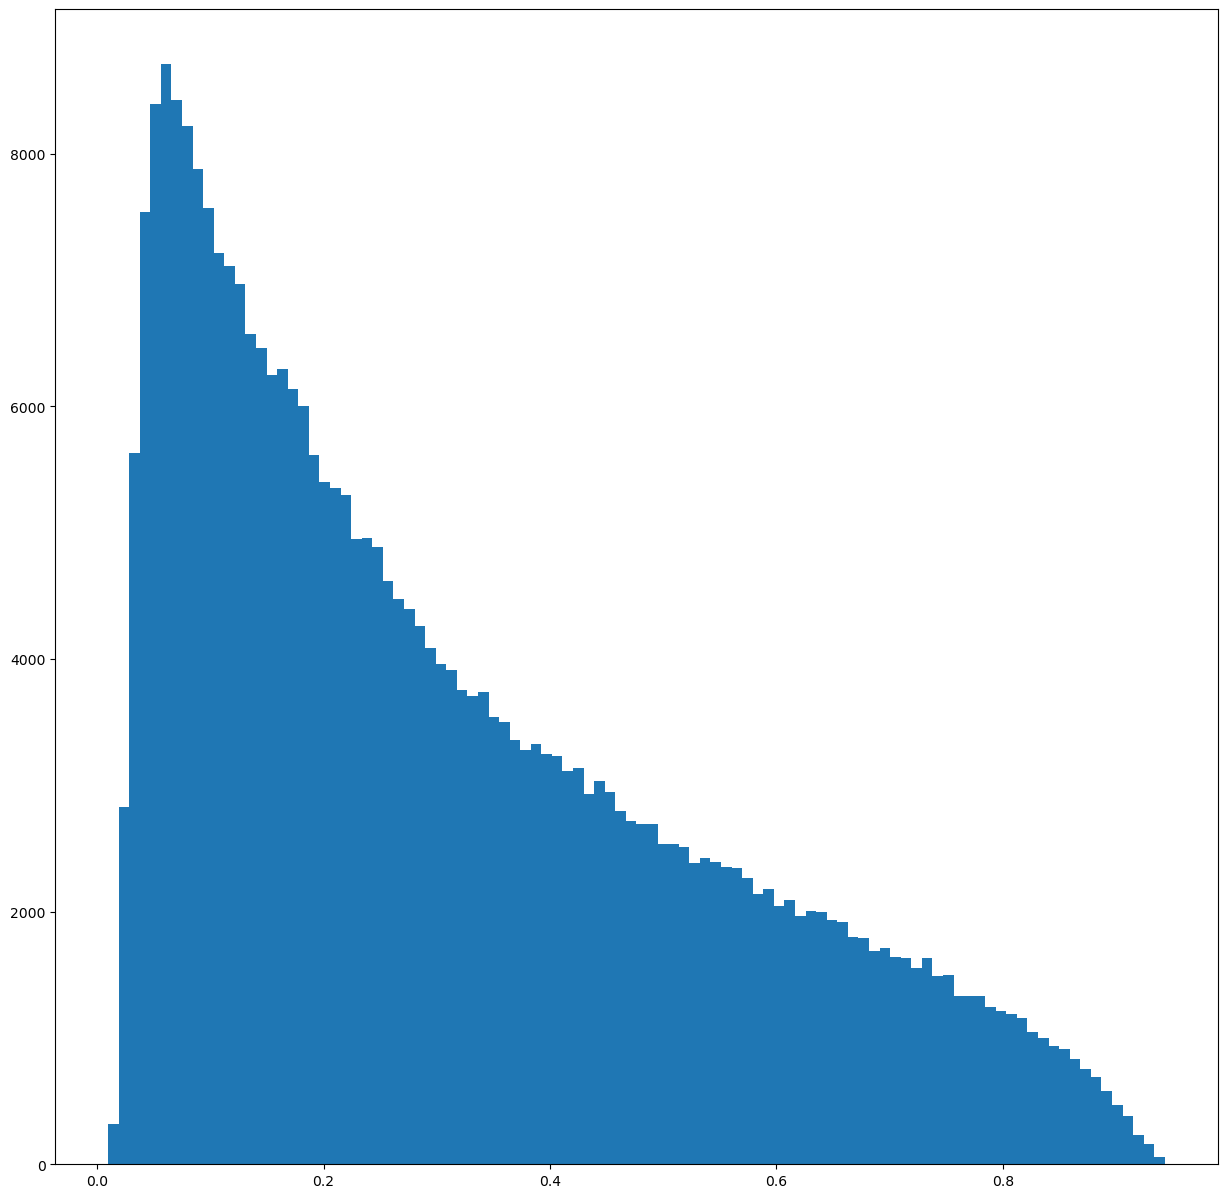

In [102]:
plt.hist(df['bdt_dc'], bins=100)

In [103]:
bdt_cutval=0.75

In [104]:
dfcut = df.query(f"bdt_dc > {bdt_cutval}")
c = mygroupby(dfcut, 'category')
import categories4 as f
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c['simplified_name'] = c.apply(lambda row: f.detailed_to_simplified_category_mapping.get(row['name'], 'NA'), axis=1)
c

,category,count,Percentage,cumulative %,name,simplified_name
0,19,4276,23.864271,23.864271,Xc_signal_Ypis_displaced_fromB0_fromDp,doubleCharm
1,24,2962,16.530863,40.395133,Xc_signal_Ypis_displaced_fromBs_fromTau,signal
2,22,2225,12.417681,52.812814,Xc_signal_Ypis_displaced_fromBs_fromDp,doubleCharm
3,0,1507,8.410537,61.223351,Xc_background,Xc_background
4,14,1398,7.802210,69.025561,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,doubleCharm
5,20,1156,6.451613,75.477174,Xc_signal_Ypis_displaced_fromBp_fromD0,doubleCharm
6,18,1026,5.726086,81.203259,Xc_signal_Ypis_displaced_fromBs_fromDs,doubleCharm
7,23,972,5.424713,86.627972,Xc_signal_Ypis_displaced_fromBp_fromDp,doubleCharm
8,7,657,3.666704,90.294676,Xc_signal_Ypis_nomatch_doubleCharm,doubleCharm
9,25,278,1.551512,91.846188,Xc_signal_Ypis_displaced_fromB0_fromD0,doubleCharm


There are 17 categories represented by more than 100 candidates

## Using the Kolmogorov-Smirnov test to see which distributions are similar

In [105]:
def find_clusters(m, threshold):
    allsets = set()
    for i in m.index:
        s = frozenset(m[m[i] > threshold][i].index)
        if s:
            allsets.add(s)
    return allsets

# Iterative
def merge_clusters(clusters):
    final = []
    tomerge = list(clusters)
    while True:
        h = tomerge[0]
        t = tomerge[1:]
        if not t:
            final.append(h)
            break
        tmp = []
        merged = False
        for c in t:
            if h & c:
                tmp.append( h | c)
                merged = True
            else:
                tmp.append(c)
        if not merged:
            final.append(h)
        tomerge = tmp
    return final

def merge_clusters_rec(unmerged, merged):
    """ Merge sets with non null intersection """
    h = unmerged[0]
    t = unmerged[1:]
    
    # End of recursion if ony one element in the list,nothing to merge to....
    if not t:
        merged.append(h)
        return t, merged
    
    # Iterate over the list of elements, comparing the first one h,
    # with all the others. If h has no intersection we add it to the
    # list of processed elements (merged), otherwise we merge it to the
    # element in common and we iterate the function again on the 
    # new list containing this new element plus the others
    tmp = []
    was_merged = False
    for c in t:
        if h & c:
            tmp.append( h | c)
            was_merged = True
        else:
            tmp.append(c)
    if not was_merged:
        merged.append(h)

    return merge_clusters_rec(tmp, merged)


def find_and_merge_clusters(m, threshold=0.5):
    clusters = find_clusters(m, threshold)
    unmerged, merged = merge_clusters_rec(list(clusters), [])
    return [ list(s) for s in merged ]


In [106]:
from scipy.stats import ks_2samp

def similar_categories(df, shown_number=17):
    """ Finding which categories have similar histograms for q2_2, tauY_2, bdt_all """
    
    # Grouping the samples per category
    c = mygroupby(df, 'category')
    c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
    
    # Preparing the list of categories to process
    #shown_number=17
    shown_categs = list(c.head(shown_number)['category'])
  
    # Building a list of detasets filtered 
    datasets = { f"{c}":  df.query(f"category == {c}") for c in shown_categs }
    datasets["others"] =  df.query(f"category not in {shown_categs}")
    datasets_names = [ f"{c}:" + categories[f"{c}"] for c in shown_categs]
    datasets_names.append("others")
    
    # List of column names
    cols = np.array([ str(c) for c in shown_categs ] + [ "others" ])

    # Preparing the matrix with the final results
    stats= pd.DataFrame(np.zeros((shown_number +1, shown_number + 1)), columns=cols)
    stats["name"] = cols.T
    stats = stats.set_index("name", drop=True).copy()

    stats_q2_2 = stats.copy()
    stats_tauY_2 = stats.copy()
    stats_bdt_all = stats.copy()
    print(cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            # Only deal with half the matrix
            if j > i:
                continue
            
            todo = { "q2_2": stats_q2_2,
                     "tauY_2": stats_tauY_2,
                     "bdt_dc": stats_bdt_all,
                   }
            for myvar, matrix in todo.items():
                res = ks_2samp(datasets[cols[i]][myvar], datasets[cols[j]][myvar], alternative='two-sided', method='exact')
                print(res)
                print(res[1])
                matrix[cols[i]][cols[j]] = res[1]
                matrix[cols[j]][cols[i]] = matrix[cols[i]][cols[j]] 
    return stats_q2_2, stats_tauY_2, stats_bdt_all

In [107]:
shown_number=17
sq2_2, stauY_2, sbdt_all = similar_categories(dfcut, shown_number)

['19' '24' '22' '0' '14' '20' '18' '23' '7' '25' '16' '26' '29' '21' '13'
 '27' '15' 'others']
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.00896590686416626, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.00010609076196697748, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.7500069, statistic_sign=1)
1.0
KstestResult(statistic=0.1304852105465614, pvalue=2.007325264835059e-26, statistic_location=6.08159114359474, statistic_sign=-1)
2.007325264835059e-26
KstestResult(statistic=0.38146819489018685, pvalue=1.7492985064055922e-227, statistic_location=0.0006530804661470057, statistic_sign=1)
1.7492985064055922e-227
KstestResult(statistic=0.2708460581775139, pvalue=1.981529652436812e-113, statistic_location=0.8348238, statistic_sign=-1)
1.981529652436812e-113
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.011550753189086913, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0, statis

KstestResult(statistic=0.730106664914471, pvalue=1.087e-321, statistic_location=7.246021136671066, statistic_sign=1)
1.087e-321
KstestResult(statistic=0.17626431872440151, pvalue=1.5471063955687188e-19, statistic_location=0.000855108166918021, statistic_sign=1)
1.5471063955687188e-19
KstestResult(statistic=0.2401371093151105, pvalue=4.909213101834468e-36, statistic_location=0.822154, statistic_sign=1)
4.909213101834468e-36
KstestResult(statistic=0.5755570818959217, pvalue=1.200177145051744e-187, statistic_location=6.611374928007126, statistic_sign=1)
1.200177145051744e-187
KstestResult(statistic=0.10150810189227401, pvalue=6.204494726929814e-06, statistic_location=0.0005788492956848403, statistic_sign=-1)
6.204494726929814e-06
KstestResult(statistic=0.18232717752502617, pvalue=3.261233064457467e-18, statistic_location=0.82856995, statistic_sign=1)
3.261233064457467e-18
KstestResult(statistic=0.4346351094713417, pvalue=5.505179501052332e-101, statistic_location=6.231616195946692, statis

KstestResult(statistic=0.1093637200965871, pvalue=0.008569884842572005, statistic_location=0.0006487271564536083, statistic_sign=-1)
0.008569884842572005
KstestResult(statistic=0.04561126185556745, pvalue=0.7187425237979337, statistic_location=0.82109493, statistic_sign=-1)
0.7187425237979337
KstestResult(statistic=0.47652404392275655, pvalue=1.0372268080212252e-45, statistic_location=6.372035626500846, statistic_sign=-1)
1.0372268080212252e-45
KstestResult(statistic=0.03919671280519444, pvalue=0.8739597465445109, statistic_location=0.0006507325185140755, statistic_sign=-1)
0.8739597465445109
KstestResult(statistic=0.12735075097816484, pvalue=0.0014793650911083174, statistic_location=0.8212914, statistic_sign=-1)
0.0014793650911083174
KstestResult(statistic=0.2679041951623886, pvalue=3.556712855651944e-14, statistic_location=7.824874516756058, statistic_sign=1)
3.556712855651944e-14
KstestResult(statistic=0.2358631613227936, pvalue=4.852386943834606e-11, statistic_location=0.0009401811

KstestResult(statistic=0.11941609503095198, pvalue=0.08724623756098722, statistic_location=0.855627, statistic_sign=-1)
0.08724623756098722
KstestResult(statistic=0.5906154568945267, pvalue=2.255960531255286e-30, statistic_location=6.815557136181355, statistic_sign=1)
2.255960531255286e-30
KstestResult(statistic=0.421599718111346, pvalue=3.2426077551987847e-15, statistic_location=0.0006356054380545783, statistic_sign=-1)
3.2426077551987847e-15
KstestResult(statistic=0.1132252760159737, pvalue=0.17095194307797215, statistic_location=0.80417186, statistic_sign=-1)
0.17095194307797215
KstestResult(statistic=0.915665729619218, pvalue=4.4906776485970624e-80, statistic_location=6.884190385204792, statistic_sign=1)
4.4906776485970624e-80
KstestResult(statistic=0.1306542294914388, pvalue=0.08670105674186554, statistic_location=0.0009567029558209428, statistic_sign=-1)
0.08670105674186554
KstestResult(statistic=0.03731152568361871, pvalue=0.9990327165144247, statistic_location=0.78127015, stati

KstestResult(statistic=0.24929535585303755, pvalue=3.0511254559469596e-06, statistic_location=0.80388105, statistic_sign=1)
3.0511254559469596e-06
KstestResult(statistic=0.1793011029790743, pvalue=0.0021437223605705515, statistic_location=8.36368653569603, statistic_sign=1)
0.0021437223605705515
KstestResult(statistic=0.39827234305741677, pvalue=2.329008459372158e-15, statistic_location=0.0007390853107923895, statistic_sign=1)
2.329008459372158e-15
KstestResult(statistic=0.14238944438717657, pvalue=0.026542398650268736, statistic_location=0.79325545, statistic_sign=1)
0.026542398650268736
KstestResult(statistic=0.09778221510626252, pvalue=0.26664305123490406, statistic_location=7.108819684229374, statistic_sign=-1)
0.26664305123490406
KstestResult(statistic=0.1782994344435448, pvalue=0.0026692165977889966, statistic_location=0.0010101148354234785, statistic_sign=1)
0.0026692165977889966
KstestResult(statistic=0.09862841905967869, pvalue=0.25761539515164544, statistic_location=0.7932554

In [108]:
sq2_2

,19,24,22,0,14,20,18,23,7,25,16,26,29,21,13,27,15,others
name,,,,,,,,,,,,,,,,,,
19,1.000000e+00,2.007325e-26,8.714912e-178,1.216032e-45,2.116500e-06,3.704730e-10,2.729931e-105,1.301379e-65,1.476378e-03,9.904028e-04,4.232235e-03,5.897995e-41,3.038166e-34,5.831728e-09,9.478345e-01,4.879431e-17,1.091847e-08,7.929048e-33
24,2.007325e-26,1.000000e+00,1.374179e-99,2.217496e-19,3.292359e-07,5.757724e-32,2.409577e-166,3.524792e-33,1.116853e-03,3.962988e-01,9.975647e-01,4.711705e-29,3.526028e-53,4.059194e-19,6.141355e-03,1.130630e-11,3.840493e-04,3.048684e-22
22,8.714912e-178,1.374179e-99,1.000000e+00,1.572080e-22,2.380774e-113,2.801168e-156,1.086944e-321,3.147370e-04,1.789232e-41,3.413363e-26,3.888453e-16,3.493883e-03,1.734315e-114,8.067713e-50,7.044822e-20,7.025372e-01,2.143722e-03,4.350299e-02
0,1.216032e-45,2.217496e-19,1.572080e-22,1.000000e+00,1.300965e-33,1.819595e-59,1.200177e-187,1.504842e-06,2.778652e-09,7.215065e-08,1.216346e-04,7.904858e-13,3.358481e-68,4.932203e-25,4.640981e-07,3.511067e-04,2.666431e-01,7.488691e-05
14,2.116500e-06,3.292359e-07,2.380774e-113,1.300965e-33,1.000000e+00,3.732647e-13,5.505180e-101,2.640481e-48,1.576859e-04,1.630142e-01,3.073998e-02,1.894885e-40,3.069913e-39,1.713460e-13,1.064416e-01,2.351280e-17,1.032444e-07,5.526650e-32
20,3.704730e-10,5.757724e-32,2.801168e-156,1.819595e-59,3.732647e-13,1.000000e+00,1.263503e-43,9.233292e-80,8.982142e-13,2.049500e-07,4.138091e-07,1.807538e-55,2.655421e-20,2.072860e-04,2.691009e-02,1.813381e-25,1.260065e-14,5.563186e-48
18,2.729931e-105,2.409577e-166,1.086944e-321,1.200177e-187,5.505180e-101,1.263503e-43,1.000000e+00,1.387280e-219,5.459351e-72,1.037227e-45,4.909234e-37,1.856918e-117,8.833775e-02,8.428265e-04,4.275100e-17,1.360179e-63,1.316569e-42,7.061257e-120
23,1.301379e-65,3.524792e-33,3.147370e-04,1.504842e-06,2.640481e-48,9.233292e-80,1.387280e-219,1.000000e+00,4.286517e-21,3.556713e-14,3.207779e-09,1.255139e-06,2.043327e-89,8.147697e-37,3.522771e-13,8.380336e-02,1.284337e-01,3.888571e-02
7,1.476378e-03,1.116853e-03,1.789232e-41,2.778652e-09,1.576859e-04,8.982142e-13,5.459351e-72,4.286517e-21,1.000000e+00,4.419018e-01,9.251831e-02,1.236633e-24,6.524819e-37,3.537971e-12,7.876482e-02,2.154556e-10,7.609217e-05,5.131573e-14


In [109]:
# Prepare some data to display histogramsand add to display tools
shown_categs = list(c.head(shown_number)['category'])
datasets = { f"{c}":  dfcut.query(f"category == {c}") for c in shown_categs }
datasets["others"] =  dfcut.query(f"category not in {shown_categs}")
datasets_names = { f"{c}": f"{c}:" + categories[f"{c}"] for c in shown_categs}
datasets_names["others"] = "others"

#tauY_2: [0,0.002]ns  BDT:[0.75,1], q2: [0,11].
def plot_templates(datasets, datasets_names, myvar):
    htype = 'stepfilled'
    a = 0.30
    plt.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
    if myvar == "tauY_2":
        plt.xlim([0, 0.002])
    elif myvar == 'bdt_dc':
        plt.xlim([0.75, 1.0])
    elif myvar == 'q2_2':
        print("==== q2_2 ")
        plt.xlim([0, 11])
        plt.ylim([0, 0.5])
    plt.title(myvar)
    plt.legend()

# 
def plot_templates_in_ax(datasets, datasets_names, myvar, ax):
    htype = 'stepfilled'
    a = 0.30
    ax.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
    print(f"=== {myvar}")
    if myvar == "tauY_2":
        ax.set_xlim([0, 0.002])
        ax.set_ylim([0, 2500])
    elif myvar == 'bdt_dc':
        ax.set_xlim([0.75, 1.0])
        ax.set_ylim([0, 20])
    elif myvar == 'q2_2':
        ax.set_xlim([0, 11])
        ax.set_ylim([0, 0.4])    
    ax.set_title(myvar)
    ax.legend(loc="best")

    
def plot_templates_categs(mycategs, myvar):
    plot_templates([ datasets[d] for d in mycategs ], [ datasets_names[d] for d in mycategs ], myvar)
    
    
def plot_templates_categs_in_ax(mycategs, myvar, ax):
    plot_templates_in_ax([ datasets[d] for d in mycategs ], [ datasets_names[d] for d in mycategs ], myvar, ax)

## Checking q2_2 distributions

In [110]:
disp_sq2_2 = sq2_2.copy()
disp_sq2_2.rename(categories, axis=1, inplace=True)
disp_sq2_2.rename(categories, axis=0, inplace=True)

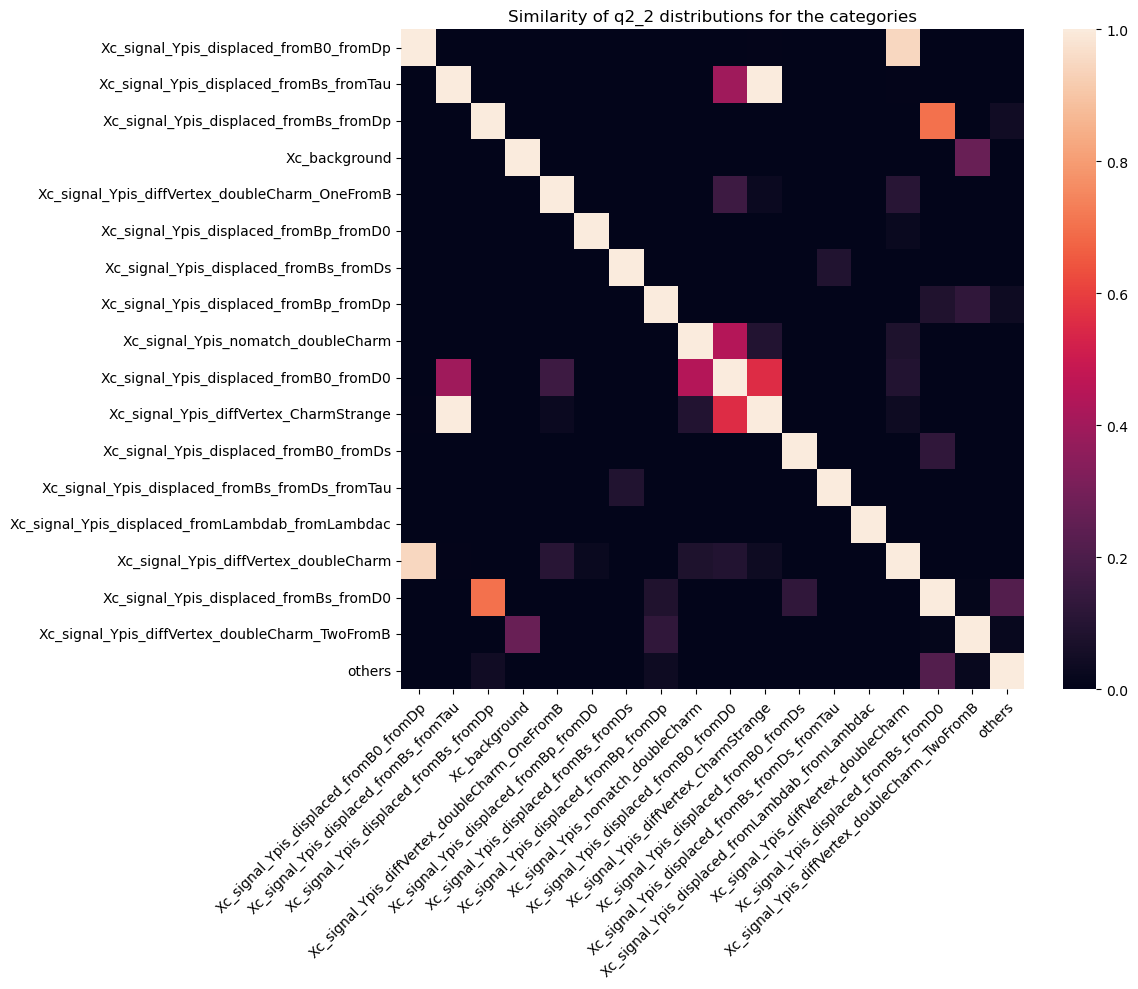

In [111]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
sn.heatmap(disp_sq2_2)
plt.title("Similarity of q2_2 distributions for the categories");
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_sq2_2.png",  bbox_inches="tight")

In [112]:
from pprint import pprint
clusters = find_and_merge_clusters(sq2_2, 0.05)
pprint(clusters)
clusters_q2_2 = clusters

[['20'],
 ['29', '18'],
 ['21'],
 ['25', '14', '13', '7', '19', '16', '24'],
 ['27', 'others', '15', '23', '26', '22', '0']]


In [113]:
from itertools import zip_longest
pages =  list(zip_longest(*(iter(clusters),) * 6))
pages

[(['20'],
  ['29', '18'],
  ['21'],
  ['25', '14', '13', '7', '19', '16', '24'],
  ['27', 'others', '15', '23', '26', '22', '0'],
  None)]

In [114]:
def plot_page(var, page, pages, nbrows=3):
    plt.rcParams["figure.figsize"] = (12, nbrows * 6)
    mypage = pages[page]#[ p for p in pages[page] if p is not None ]
    nbcols = 2
    fig, axs = plt.subplots(nbrows, 2)
    print(mypage)
    print(axs.shape)
    for row in range(nbrows):
        c0 = mypage[2 *row]
        c1 = mypage[2 * row + 1]
        if c0:
            plot_templates_categs_in_ax(c0, var, axs[row][0])
        else:
              axs[row][0].axis('off')
        if c1:
            plot_templates_categs_in_ax(c1, var, axs[row][1])
        else:
              axs[row][1].axis('off')
        plt.tight_layout()
        plt.savefig(f"templates_hist_{var}_{page}.png")

(['20'], ['29', '18'], ['21'], ['25', '14', '13', '7', '19', '16', '24'], ['27', 'others', '15', '23', '26', '22', '0'], None)
(3, 2)
=== q2_2
=== q2_2
=== q2_2
=== q2_2
=== q2_2


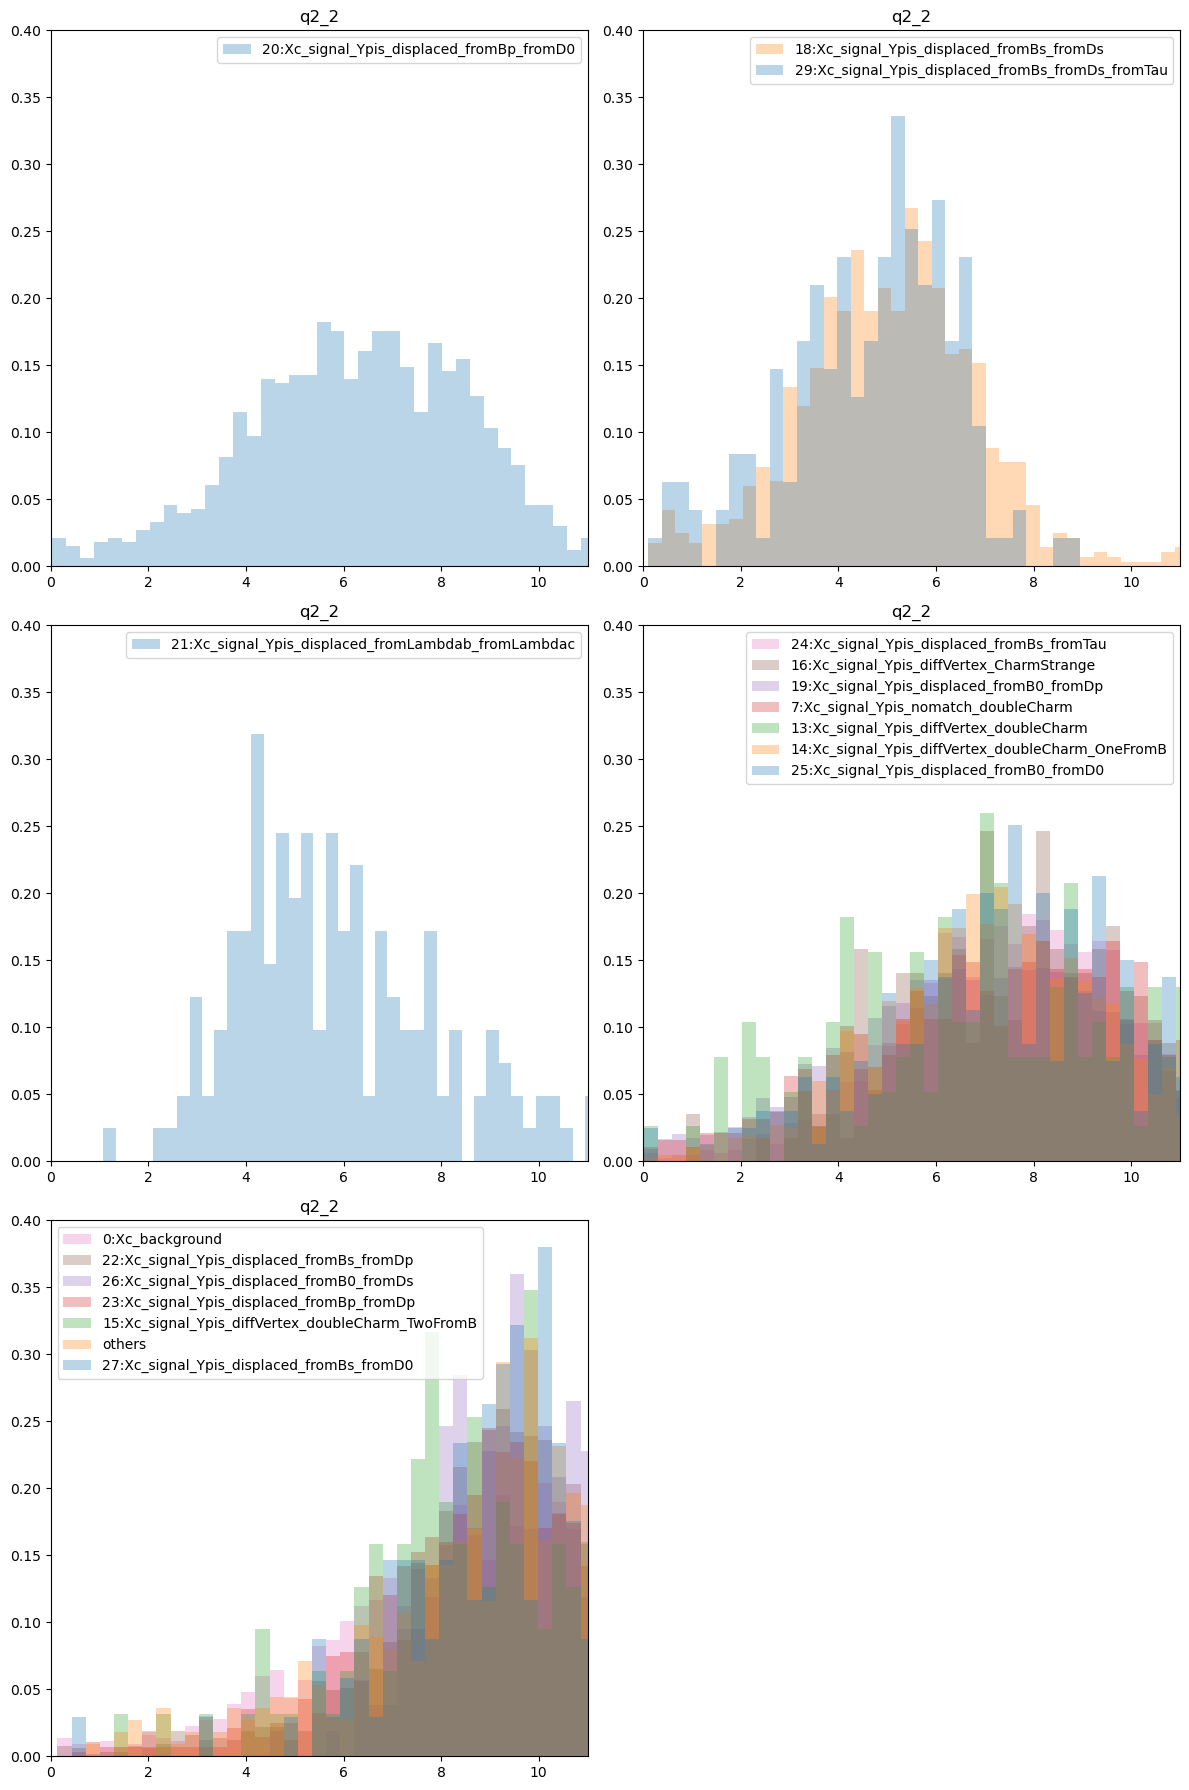

In [115]:
plot_page("q2_2", 0, pages)

## Checking tauY_2 distributions

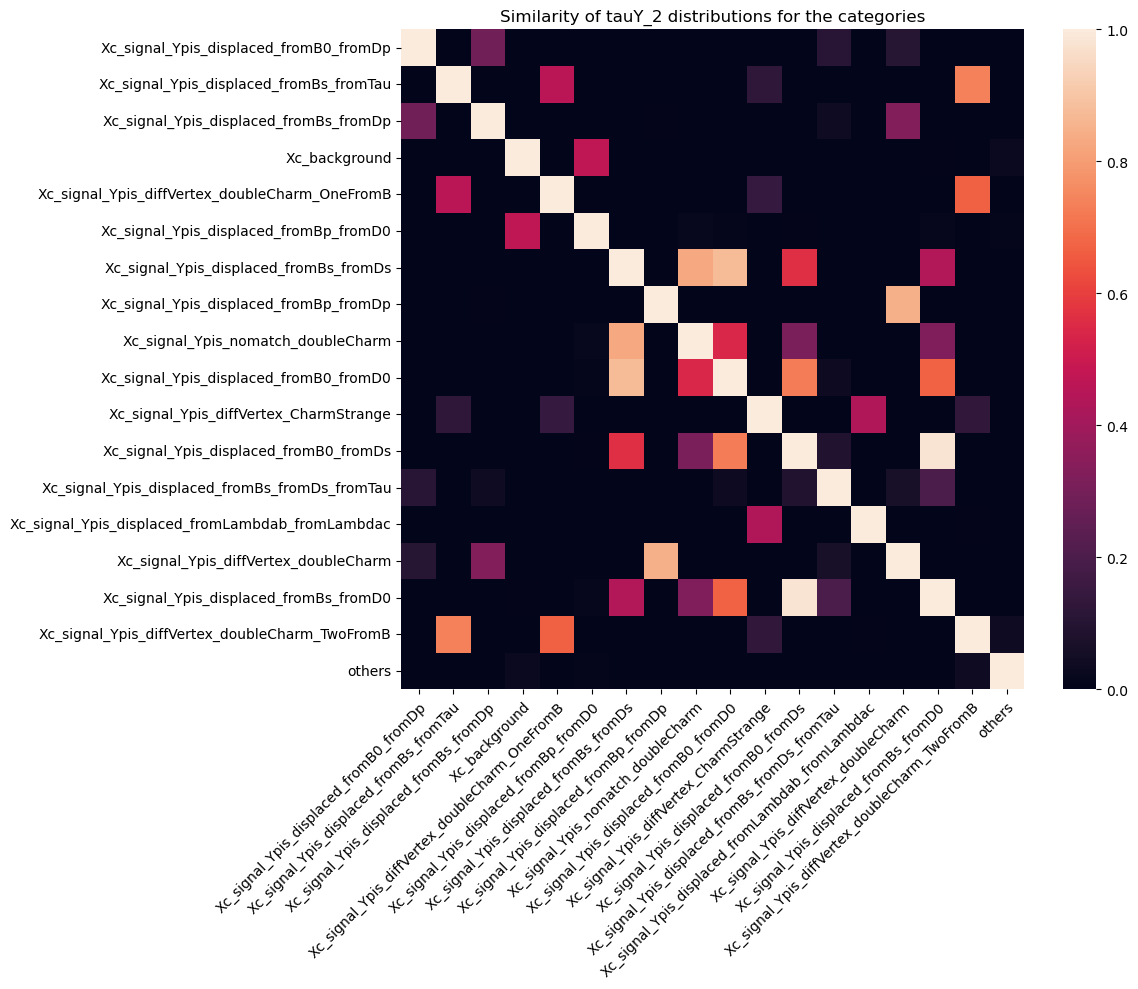

In [116]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
disp_stauY_2 = stauY_2.copy()
disp_stauY_2.rename(categories, axis=1, inplace=True)
disp_stauY_2.rename(categories, axis=0, inplace=True)
plt.title("Similarity of tauY_2 distributions for the categories");
sn.heatmap(disp_stauY_2)
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_stauY_2.png",  bbox_inches="tight")



In [117]:
from pprint import pprint
clusters = find_and_merge_clusters(stauY_2, 0.05)
pprint(clusters)

clusters_tauY_2 = clusters

[['14', '15', '16', '21', '24'],
 ['others'],
 ['20', '0'],
 ['13', '7', '27', '29', '23', '26', '18', '25', '19', '22']]


In [118]:
from itertools import zip_longest
pages =  list(zip_longest(*(iter(clusters_tauY_2),) * 6))
pages

[(['14', '15', '16', '21', '24'],
  ['others'],
  ['20', '0'],
  ['13', '7', '27', '29', '23', '26', '18', '25', '19', '22'],
  None,
  None)]

(['14', '15', '16', '21', '24'], ['others'], ['20', '0'], ['13', '7', '27', '29', '23', '26', '18', '25', '19', '22'], None, None)
(2, 2)
=== tauY_2
=== tauY_2
=== tauY_2
=== tauY_2


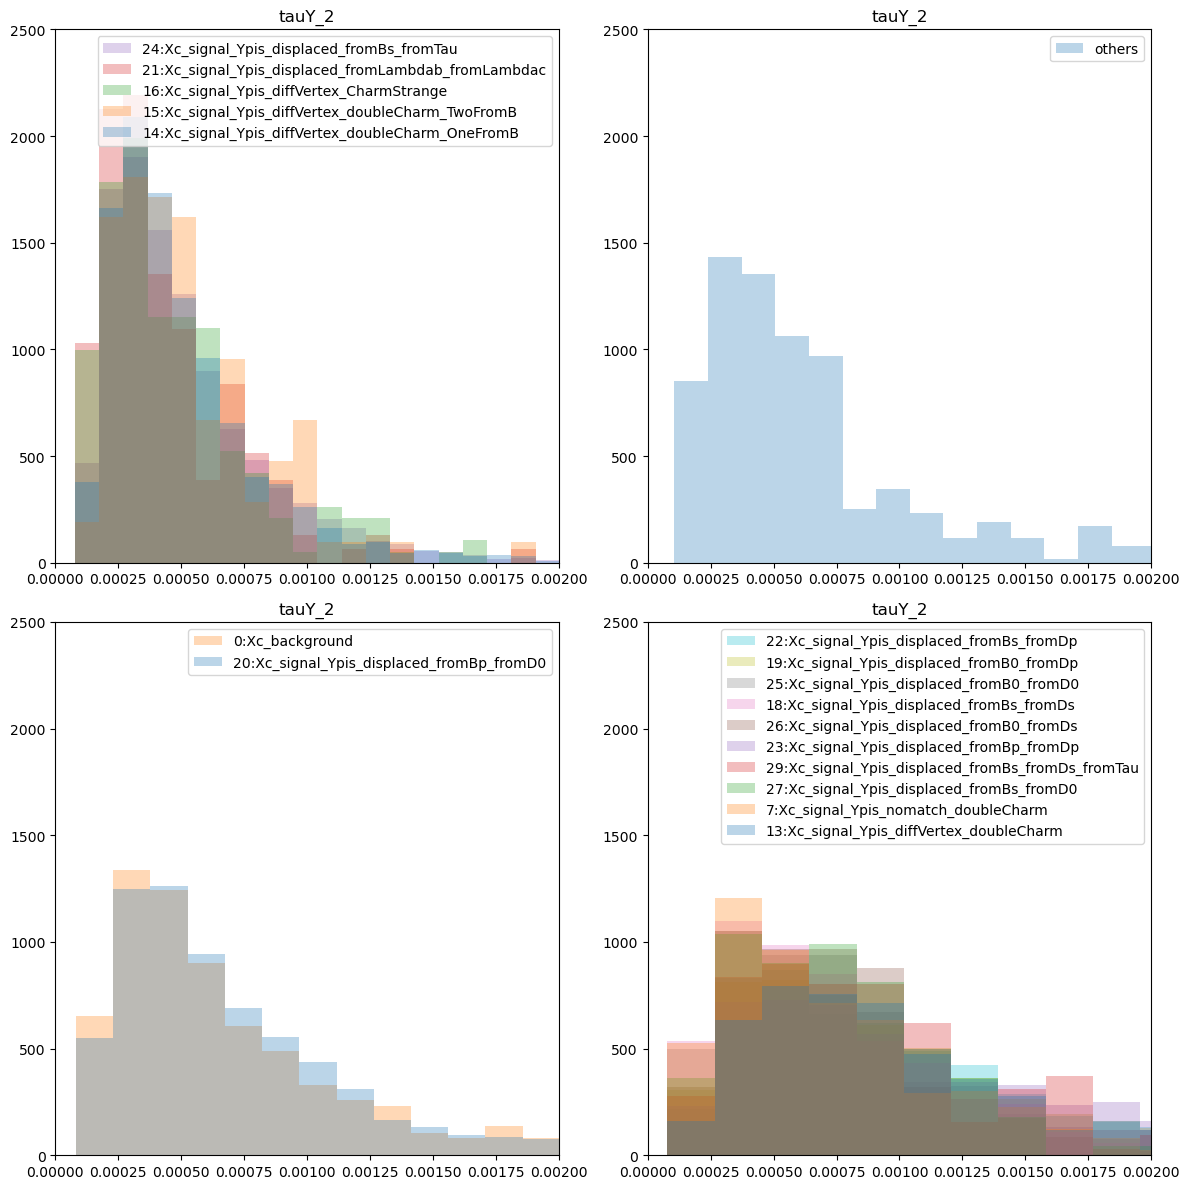

In [119]:
plot_page("tauY_2", 0, pages, nbrows=2)
# plt.rcParams["figure.figsize"] = (15,4)
# for c in clusters:
#     plt.figure()
#     plot_templates_categs(c, 'tauY_2')

## Checking bdt_all distributions

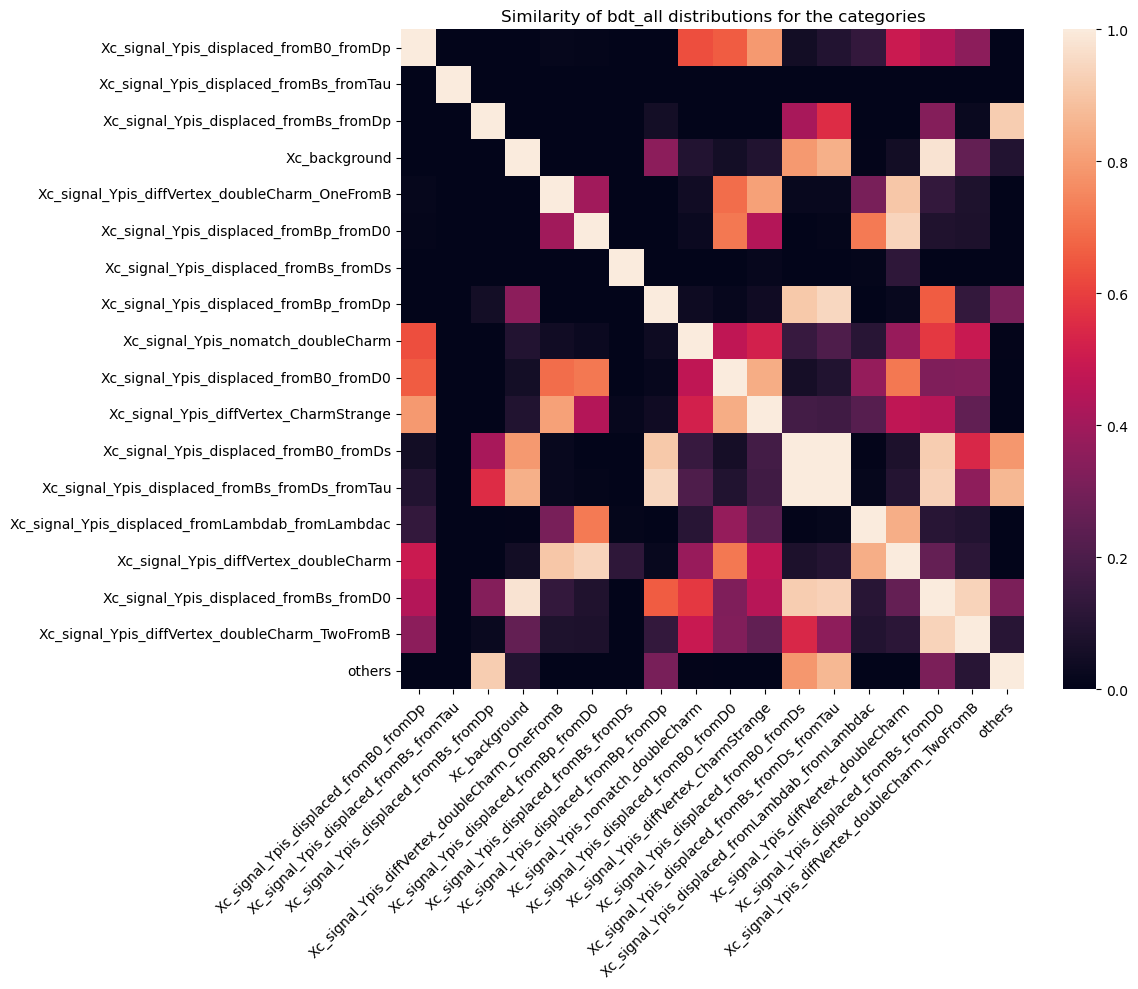

In [120]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
disp_sbdt_all = sbdt_all.copy()
disp_sbdt_all.rename(categories, axis=1, inplace=True)
disp_sbdt_all.rename(categories, axis=0, inplace=True)
sn.heatmap(disp_sbdt_all)
plt.title("Similarity of bdt_all distributions for the categories");
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_sbdt_all_2.png",  bbox_inches="tight")

In [121]:
from pprint import pprint
clusters = find_and_merge_clusters(sbdt_all, 0.05)
pprint(clusters)

clusters_bdt_dc = clusters

[['24'],
 ['13',
  '7',
  '27',
  '15',
  '29',
  '16',
  '23',
  '21',
  '26',
  '18',
  '25',
  '14',
  'others',
  '19',
  '22',
  '20',
  '0']]


In [122]:
from itertools import zip_longest
pages =  list(zip_longest(*(iter(clusters_bdt_dc),) * 6))
pages

[(['24'],
  ['13',
   '7',
   '27',
   '15',
   '29',
   '16',
   '23',
   '21',
   '26',
   '18',
   '25',
   '14',
   'others',
   '19',
   '22',
   '20',
   '0'],
  None,
  None,
  None,
  None)]

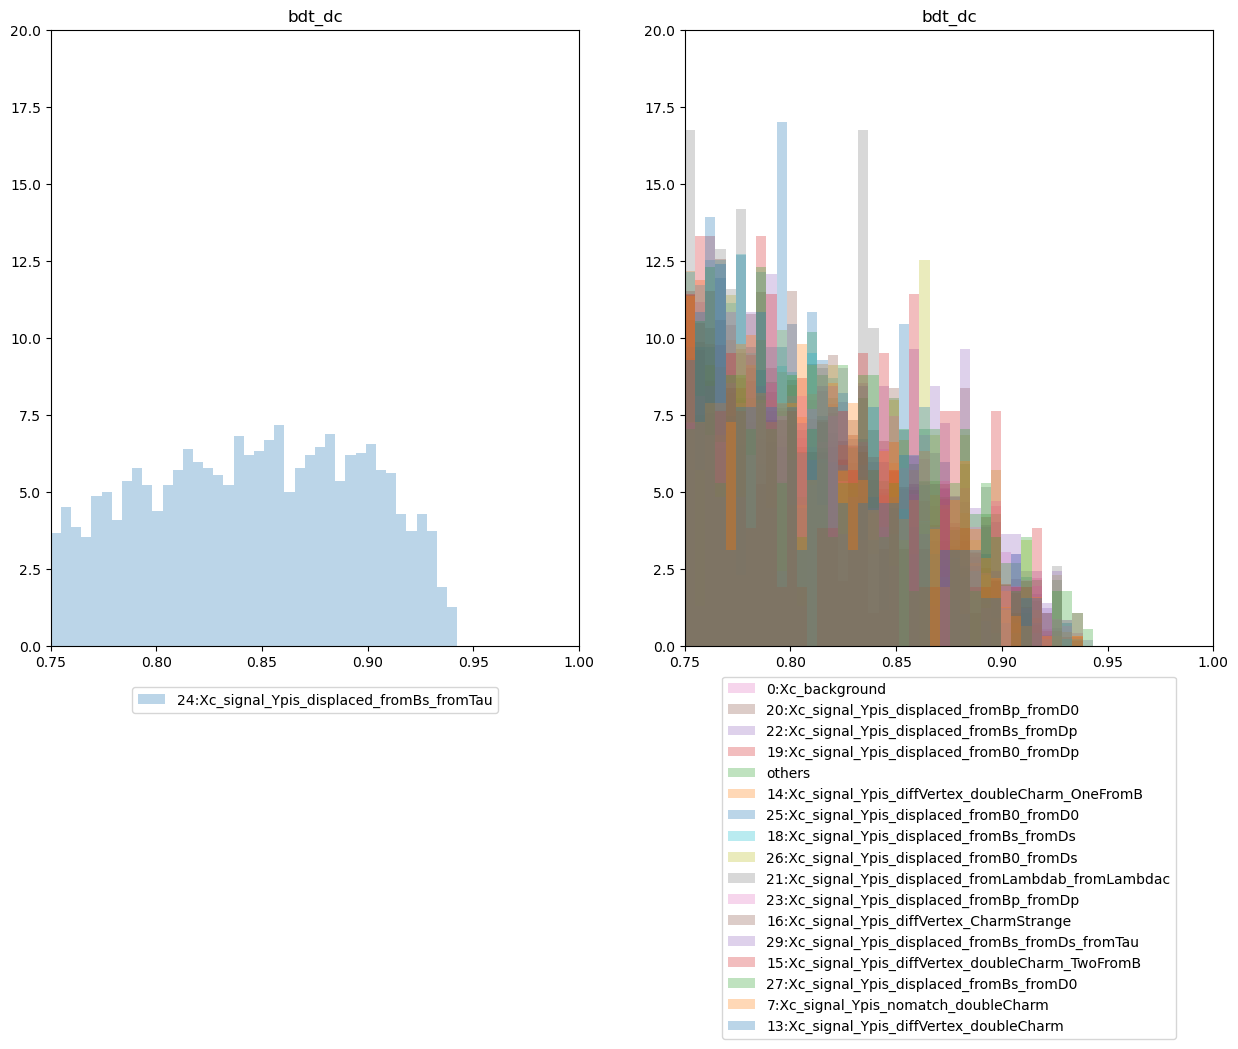

In [123]:

legends = []
def plot_templates_in_ax_custom(datasets, datasets_names, myvar, ax, bbox_to_anchor, loc):
    htype = 'stepfilled'
    a = 0.30
    ax.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
    ax.set_xlim([0.75, 1.0])
    ax.set_ylim([0, 20])
    ax.set_title(myvar)
    legends.append(ax.legend(bbox_to_anchor=bbox_to_anchor, loc=loc))

plt.rcParams["figure.figsize"] = (15, 8)
fig, axs = plt.subplots(1, 2) 

plot_templates_in_ax_custom([ datasets[d] for d in clusters_bdt_dc[0] ], [ datasets_names[d] for d in clusters_bdt_dc[0] ], 'bdt_dc', axs[0], (0.5,-0.12), 'lower center' )
plot_templates_in_ax_custom([ datasets[d] for d in clusters_bdt_dc[1] ], [ datasets_names[d] for d in clusters_bdt_dc[1] ], 'bdt_dc', axs[1], (0.5,-0.65), 'lower center' )
plt.savefig(f"templates_hist_bdt_dc_0.png", bbox_extra_artists=legends, bbox_inches='tight')

In [124]:
def merge_clusters(clusters_bdt_dc, clusters_q2_2, clusters_tauY_2):
    print(clusters_bdt_dc)
    print(len(clusters_bdt_dc))
    print(clusters_q2_2)
    print(len(clusters_q2_2))
    print(clusters_tauY_2)
    print(len(clusters_tauY_2))
    
merge_clusters(clusters_bdt_dc, clusters_q2_2, clusters_tauY_2)

[['24'], ['13', '7', '27', '15', '29', '16', '23', '21', '26', '18', '25', '14', 'others', '19', '22', '20', '0']]
2
[['20'], ['29', '18'], ['21'], ['25', '14', '13', '7', '19', '16', '24'], ['27', 'others', '15', '23', '26', '22', '0']]
5
[['14', '15', '16', '21', '24'], ['others'], ['20', '0'], ['13', '7', '27', '29', '23', '26', '18', '25', '19', '22']]
4


In [125]:
threshold=0.05
clusters_q2_2 = find_and_merge_clusters(sq2_2, threshold)
clusters_bdt_dc = find_and_merge_clusters(sbdt_all, threshold)
clusters_tauY_2 = find_and_merge_clusters(stauY_2, threshold)
merge_clusters(clusters_bdt_dc, clusters_q2_2, clusters_tauY_2)

[['24'], ['13', '7', '27', '15', '29', '16', '23', '21', '26', '18', '25', '14', 'others', '19', '22', '20', '0']]
2
[['20'], ['29', '18'], ['21'], ['25', '14', '13', '7', '19', '16', '24'], ['27', 'others', '15', '23', '26', '22', '0']]
5
[['14', '15', '16', '21', '24'], ['others'], ['20', '0'], ['13', '7', '27', '29', '23', '26', '18', '25', '19', '22']]
4


In [126]:
res = [24, 20, [18, 29], 21, ['25', '13', '19', '7'], [16, 14,], 'others', [23, 22, 26, 27], 0, [15]]


In [127]:
f.categories_map[10]

'Xc_signal_Ypis_diffVertex_signal'

In [128]:
f.categories_map[11]


'Xc_signal_Ypis_diffVertex_tauFromB'